# Curriculum Learning — Academic Summary

**Authors:** Yoshua Bengio, Jérôme Louradour, Ronan Collobert, Jason Weston
**Venue:** ICML 2009

# https://dl.acm.org/doi/epdf/10.1145/1553374.1553380

## Abstract
This paper formalizes the intuitive human/animal pedagogical strategy of presenting training examples in a meaningful order — from simple to complex — as a machine learning training strategy termed "curriculum learning." The authors argue that a well-designed curriculum can act as a continuation method for non-convex optimization, improving both convergence speed and generalization quality. This hypothesis is validated across several toy and real experiments involving perceptrons, shape recognition, and language modeling.

## Problems
- Training deep, non-convex neural architectures is difficult: gradient descent is prone to poor local minima that are hard to escape when initialized randomly.
- Standard training presents examples in random order, giving no special treatment to example difficulty or informativeness, which can slow convergence and yield worse generalization.
- Cognitive science research (Elman, 1993; Rohde & Plaut, 1999) had left open whether "starting small" — a strategy known to aid human/animal learning (shaping) — could similarly benefit machine learning algorithms, with conflicting prior evidence.

## Proposed Solutions
The authors propose **curriculum learning**: organizing training so that easier examples (or simpler sub-concepts) are presented before harder ones, gradually increasing task/example difficulty over training.

Formally, given a target distribution $$P(z)$$ over examples $$z$$, a curriculum is a sequence of distributions:

$$
Q_\lambda(z) \propto W_\lambda(z) P(z), \quad \forall z, \quad 0 \leq \lambda \leq 1
$$

with $$Q_1(z) = P(z)$$, satisfying:

$$
H(Q_\lambda) < H(Q_{\lambda+\epsilon}) \quad \forall \epsilon > 0
$$

$$
W_{\lambda+\epsilon}(z) \geq W_\lambda(z) \quad \forall z, \forall \epsilon > 0
$$

i.e., entropy (diversity) of the training distribution increases monotonically, and example weights are non-decreasing over the curriculum sequence. This connects curriculum learning to **continuation methods** in global optimization, where a smoothed version of a non-convex objective $$C_0(\theta)$$ is optimized first, then gradually deformed toward the true objective $$C_1(\theta)$$, guiding parameters into better basins of attraction.

## Purpose
To empirically test whether ordering training examples by difficulty (curriculum) improves:
1. Speed of convergence during optimization.
2. Quality of the local minima found (generalization/test error), particularly for non-convex, deep architectures.
3. To position curriculum learning theoretically as a continuation method and relate it to unsupervised pre-training, boosting, transfer learning, and active learning.

## Methodology
Four experimental settings were used, ranging from convex to highly non-convex problems:

1. **Convex, cleaner examples (SVM):** Two-class 2D Gaussian data; linear SVM trained with random init, comparing training on "easy" examples (correct side of Bayes decision surface) vs. all examples.

2. **Convex, online Perceptron:** Synthetic binary classification with relevant/irrelevant input features; examples ranked by (a) number of noisy irrelevant inputs, (b) margin $$yw'x$$. Compared curriculum vs. no-curriculum vs. anti-curriculum ordering across increasing input dimensions.

3. **Non-convex, shape recognition:** 32×32 grayscale images classified into 3 shape classes using a 3-hidden-layer neural network trained via stochastic gradient descent on negative conditional log-likelihood. Two datasets: **BasicShapes** (low variability: squares, circles, equilateral triangles) as "easy" and **GeomShapes** (rectangles, ellipses, triangles) as target. Curriculum = 2-step schedule (train on BasicShapes until a "switch epoch," then GeomShapes). Compared against no-curriculum baseline and a control trained on the union of both datasets (to rule out "more examples" as the sole explanation).

4. **Non-convex, language modeling:** Deep neural network (embedding lookup table, dimension $$d=50$$, 100 hidden units) trained via ranking loss:

$$
C_s = \sum_{w \in D} \frac{1}{|D|} C_{s,w} = \sum_{w \in D} \frac{1}{|D|} \max(0, 1 - f(s) + f(s^w))
$$

on 631 million 5-word windows from Wikipedia. Curriculum strategy = progressively growing vocabulary size (starting at 5,000 most frequent words, increasing by 5,000 per pass) versus training directly with the full 20,000-word vocabulary.

## Results
- **SVM (convex):** Training only on easy examples yielded lower average test error (16.3% vs. 17.1%), a statistically significant improvement.
- **Perceptron (convex, online):** Curriculum ordering (by noise level or margin) produced statistically significant reductions in generalization error compared to no-curriculum and anti-curriculum orderings across all tested input dimensions.
- **Shape recognition (non-convex):** Best generalization occurred with a two-stage curriculum where roughly half of total training epochs were spent on BasicShapes before switching to GeomShapes; this outperformed both the no-curriculum baseline and the union-dataset control, indicating the benefit is not merely from seeing more data but from a genuinely different (better) local minimum.
- **Language modeling (non-convex):** The curriculum-trained model's target-distribution log-rank error crossed below the no-curriculum model's error after about 1 billion updates and continued to improve; final average log-ranks were 2.78 (curriculum) vs. 2.83 (no-curriculum), a statistically significant difference.
- Across settings, curriculum strategies appeared to act as an implicit **regularizer**, with benefits most pronounced on test/generalization error rather than training error, and also improved convergence speed even in convex settings.

## Conclusions
- Empirical evidence across convex and non-convex, small-scale and large-scale (vision, language) tasks supports the hypothesis that curriculum strategies can improve both optimization speed and generalization.
- Curriculum learning is theoretically framed as a form of continuation method for non-convex optimization, sharing conceptual similarities with unsupervised pre-training (both help find better basins of attraction and act as regularizers).
- The approach is also connected to boosting (both emphasize a changing distribution over examples, but curriculum starts with easy examples rather than uniform weighting), and to transfer/multi-task/lifelong learning (curriculum uses early "tasks" to guide optimization toward better solutions on the final task).
- Open questions remain regarding what constitutes an optimal curriculum and how to design curricula automatically; the authors suggest future work could incorporate active-selection strategies that adaptively focus on examples near the "frontier" of a learner's current competence, rather than following a fixed, teacher-defined schedule.

# Mathematical and Statistical Content Summary — "Curriculum Learning"

## 1. Curriculum as a Reweighted Training Distribution

**Equation (1):**
$$
Q_\lambda(z) \propto W_\lambda(z) P(z) \quad \forall z
$$

**Explanation:** Here $z$ is a training example, $P(z)$ is the true (target) data distribution, and $W_\lambda(z) \in [0,1]$ is a weight applied to example $z$ at curriculum "stage" $\lambda$. $Q_\lambda(z)$ is the training distribution actually used at stage $\lambda$ — it's the target distribution reweighted (some examples emphasized, others suppressed). This formalizes the idea that early in training we sample more from "easy" examples and less (or not at all) from "hard" ones.

**Equation (2):**
$$
Q_1(z) = P(z) \quad \forall z
$$

**Explanation:** At the end of the curriculum ($\lambda = 1$), all weights become 1, so the training distribution equals the true target distribution — i.e., the curriculum eventually reduces to ordinary training on the full data.

## 2. Formal Definition of a Curriculum (Entropy and Monotonicity Conditions)

**Equation (3) — Increasing entropy:**
$$
H(Q_\lambda) < H(Q_{\lambda+\epsilon}) \quad \forall \epsilon > 0
$$

**Explanation:** $H(\cdot)$ denotes the entropy (a measure of randomness/diversity) of a distribution. This condition says that as the curriculum progresses ($\lambda$ increases), the training distribution must become more diverse/spread out — the learner sees an increasingly varied set of examples, not a shrinking or static one.

**Equation (4) — Monotonic weights:**
$$
W_{\lambda+\epsilon}(z) \geq W_\lambda(z) \quad \forall z,\ \forall \epsilon > 0
$$

**Explanation:** The weight of any given example can only stay the same or increase as the curriculum advances — examples are never "removed" or down-weighted once introduced. Together, (3) and (4) mathematically capture the intuitive notion of a curriculum: start narrow and simple, then broaden and include harder cases, without ever un-teaching what was learned.

## 3. Continuation Method Framework

**General continuation method:**
$$
C_\lambda(\theta), \quad C_0 \text{ easy to optimize (e.g., convex)}, \quad C_1 = \text{true objective}
$$

**Explanation:** A continuation method solves a hard, non-convex optimization problem $C_1(\theta)$ by first solving an easier, smoothed version $C_0(\theta)$, then slowly morphing $C_0$ into $C_1$ while tracking the local minimum. The idea is that the smoothed problem has a simpler optimization landscape (fewer or no bad local minima), so tracking its solution as smoothing decreases tends to land in a good minimum of the true problem. Curriculum learning is proposed as a special case of this, where "smoothing" corresponds to training-set reweighting/simplification rather than an explicit mathematical smoothing operator.

## 4. Easiness Criteria in the Perceptron Experiment

**Target function:**
$$
y = \text{sign}(w'x_{\text{relevant}})
$$

**Explanation:** A binary classification rule where the true label depends only on "relevant" input features via a linear threshold. Some input dimensions are "irrelevant" noise; examples are called easier when more irrelevant dimensions are zeroed out (less noise) or when the margin is larger.

**Margin as an easiness measure:**
$$
y w' x
$$

**Explanation:** The margin measures how confidently/correctly an example is classified by the true (Bayes) weight vector $w$. Larger $yw'x$ means the example sits farther from the decision boundary — easier to classify correctly, hence considered "easy."

## 5. SVM Toy Experiment (Gaussian Data)

**Class-conditional means:**
$$
\mu_y = \left(\frac{y}{\sqrt{2}}, \frac{y}{\sqrt{2}}\right), \quad y \in \{-1, +1\}, \quad \text{std. dev.} = 1
$$

**Explanation:** Two classes of 2D data are generated from Gaussians with these means (equidistant from the origin in opposite directions) and unit variance, creating overlapping, noisy classes — a controlled setting to test whether excluding "hard"/mislabeled-looking examples (those on the wrong side of the Bayes decision boundary, i.e., $yw'x \le 0$) improves generalization.

**Reported result:** 16.3% test error (easy-only training) vs. 17.1% (all examples), averaged over 50 runs — a small but consistent numeric comparison of generalization error under two training regimes.

## 6. Ranking Loss for Language Modeling

**Equation (5):**
$$
C_s = \sum_{w \in D} \frac{1}{|D|} C_{s,w} = \sum_{w \in D} \frac{1}{|D|} \max\big(0,\ 1 - f(s) + f(s^w)\big)
$$

**Explanation:** For a text window $s$, $f(s)$ is the model's score for how "correct" that window is. For each possible vocabulary word $w$, $s^w$ denotes the window with its last word replaced by $w$. The loss penalizes the model whenever an incorrect substitution $s^w$ scores too close to (within margin 1 of) or higher than the correct window $s$. This is a **hinge/margin ranking loss** (similar in form to SVM hinge loss), averaged uniformly over the vocabulary $D$. In practice, gradients are estimated stochastically by sampling one random word $w$ instead of summing over the entire vocabulary, making training tractable.

## 7. Evaluation Metric: Log-Rank

**Explanation:** Model quality is measured as the average of $\log(\text{rank of the correct next word})$ across test windows, where "rank" is the position of the true word when all candidate words are sorted by model score. Lower log-rank means the correct word tends to be scored near the top — better predictive performance. This logarithmic transformation compresses the effect of large ranks, giving a more stable and interpretable scalar comparison between curriculum and no-curriculum models (reported as 2.78 vs. 2.83 in the final experiment).

## 8. Statistical Significance Testing

**Method used:** Student's t-test at the 5% significance level, applied to compare mean error rates between curriculum and no-curriculum (and anti-curriculum) conditions across repeated runs (e.g., 50 runs for the SVM experiment, 500 repetitions for the perceptron experiment, 20 seeds for the shape-recognition and language-modeling experiments).

**Explanation:** A t-test checks whether the difference between two group means (e.g., test error with vs. without curriculum) is unlikely to have occurred by chance, given the variability observed across runs. The paper reports that error differences greater than 0.01 were statistically significant at the 5% level, supporting the claim that curriculum-based improvements are not due to random variation in initialization or sampling.

## 9. Box Plot Summary Statistics (Figure 3)

**Explanation:** For the shape-recognition experiment, test error distributions across 20 random seeds are summarized using standard descriptive statistics: median (50th percentile), interquartile range (25th–75th percentile, the box), and the 5th–95th percentile range (whisker ends). This nonparametric summary displays the spread and central tendency of generalization error as a function of the "switch epoch" (when training moves from easy to target data), without assuming a specific distributional form.

## Summary of Mathematical Role in the Paper

| Concept | Role in Paper |
|---|---|
| $Q_\lambda(z) \propto W_\lambda(z)P(z)$ | Formal definition of a curriculum as a sequence of reweighted training distributions |
| Entropy condition (Eq. 3) | Ensures training distribution diversity increases over the curriculum |
| Monotonic weight condition (Eq. 4) | Ensures examples are never "forgotten" once introduced |
| Continuation method framework | Theoretical justification: curriculum learning as guided, staged non-convex optimization |
| Margin $yw'x$ | Quantitative definition of example "easiness" |
| Ranking hinge loss (Eq. 5) | Training objective for the language model, enabling efficient (sampled) gradient estimation |
| Log-rank metric | Evaluation measure for language model quality |
| t-test | Statistical validation that observed improvements are significant, not due to chance |
| Box plots | Descriptive statistics summarizing variability of results across random seeds |

# Structured Review Table — "Curriculum Learning" (Bengio et al., 2009)

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Training deep, non-convex neural architectures is prone to poor local minima, especially with random initialization. | Prior deep learning methods (pre-2006) lacked reliable optimization strategies; even later greedy layer-wise pre-training methods left open why certain training orders help find better solutions. | Introduce **curriculum learning**, in which training examples/sub-tasks are ordered from simple to complex, guiding optimization toward better regions of parameter space. |
| 2 | Uncertainty (from cognitive science) about whether "starting small" — a strategy known to aid human and animal learning (shaping) — actually benefits machine learning algorithms, given conflicting findings (Elman, 1993 vs. Rohde & Plaut, 1999). | Without a formal machine learning framework, this question could not be systematically tested or generalized beyond narrow cognitive-science simulations (e.g., recurrent grammar learning). | Formalize "starting small" as a general ML training strategy, "curriculum learning," and test it empirically across multiple task types (vision, language, toy convex settings), not just recurrent grammar tasks. |
| 3 | No formal mathematical definition existed for what constitutes a "curriculum" or an "easy" vs. "hard" example ordering. | Prior related ideas (shaping, easy-to-hard training) were described only informally or task-specifically, preventing systematic study or comparison across domains. | Provide a **formal definition** of curriculum learning via a sequence of reweighted training distributions $$Q_\lambda(z) \propto W_\lambda(z)P(z)$$ satisfying monotonic weight increase and increasing entropy conditions. |
| 4 | Lack of theoretical grounding for *why* a curriculum strategy might help with non-convex optimization. | Without a theoretical mechanism, curriculum-based improvements could only be justified empirically/anecdotally, limiting generalizability and principled design of curricula. | Connect curriculum learning to **continuation methods** in global optimization, framing the curriculum as gradually deforming an "easy" optimization surface into the true non-convex objective, helping the model settle into better basins of attraction. |
| 5 | Ambiguity in prior work about whether ordering effects were genuinely about "difficulty," or simply reflected training on more data overall. | Some earlier claims about staged/curriculum training were confounded with the fact that curriculum models effectively saw more total examples, undermining causal claims about ordering itself. | Design a **control experiment** (training on the union of easy + target datasets, without ordering) in the shape-recognition task to isolate and confirm that the benefit comes from ordering, not from extra data. |
| 6 | No empirical evidence spanning both convex and non-convex settings, and both small toy problems and realistic large-scale tasks. | Prior cognitive-science-inspired studies were narrow (e.g., single small-scale grammar task), so results could not be confidently generalized to broader classes of ML problems (classification, vision, language modeling). | Conduct a **suite of experiments** across increasing complexity: convex SVM/Perceptron toy problems, non-convex deep network shape classification, and large-scale (631M-window) neural language modeling. |
| 7 | Curriculum strategies rely heavily on manual, teacher-defined ordering (e.g., a human decides what counts as "easy"), with no principled or automated way to construct them. | This limits scalability and generality: a hand-crafted curriculum may not transfer to other tasks or domains, and requires nontrivial human effort. | Propose curriculum learning as a research direction that could later be **automated via active selection** — i.e., a learner adaptively focusing on examples near its current "frontier" of competence — as a direction for future work, connecting curriculum learning to active learning. |
| 8 | Unclear relationship between curriculum learning and other established paradigms (unsupervised pre-training, boosting, transfer/multi-task learning). | Without positioning curriculum learning relative to these methods, its novelty and mechanism of benefit (optimization aid vs. regularization vs. transfer) remained ambiguous. | Explicitly **compare and connect** curriculum learning to unsupervised pre-training (shared regularization/optimization benefits), boosting (different distribution-shifting philosophy), and transfer/multi-task/lifelong learning (curriculum as a special form of guided transfer). |

In [1]:
# ============================================================
# CURRICULUM LEARNING — Educational PyTorch Replication
# Paper: "Curriculum Learning" (Bengio, Louradour, Collobert, Weston, 2009)
# Dataset: CIFAR-10 (loaded via HuggingFace `datasets`)
# ------------------------------------------------------------
# CORE IDEA BEING REPLICATED:
#   The paper shows that training a model on "easy" examples
#   first, then gradually introducing "harder" examples,
#   can improve optimization and generalization compared to
#   training on randomly-ordered examples from the start.
#
#   Here we implement a simplified image-classification version:
#     1) We estimate an "easiness" score for every training image
#        using a quick warm-up pass (lower loss = easier example).
#     2) We build a curriculum schedule that starts training on
#        only the easiest subset of images, and gradually grows
#        the training pool to include harder images over epochs
#        (mirroring the paper's "growing vocabulary / growing
#        training set" curriculum strategy in Section 6).
#     3) We compare curriculum training against a full "no
#        curriculum" baseline is optional — here we focus on
#        demonstrating the curriculum pipeline end-to-end.
# ============================================================

# ---------------------------
# 0. INSTALLS (Colab-safe)
# ---------------------------
# NOTE: `!pip install` calls are safe to leave in a Colab cell.
!pip install -q datasets torch torchvision scikit-learn matplotlib

# ---------------------------
# 1. IMPORTS
# ---------------------------
import io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from datasets import load_dataset
from torchvision import transforms

from sklearn.metrics import confusion_matrix

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image as IPImage

In [2]:
# ---------------------------
# 2. GLOBAL WHITE THEME (applies to ALL plots in this notebook)
# ---------------------------
# We enforce a white background + black text theme globally so every
# figure (not just the final dashboard) is consistent and readable.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [3]:
# ---------------------------
# 3. REPRODUCIBILITY & DEVICE
# ---------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# ---------------------------
# 4. CLASS NAMES (CIFAR-10, labels 0-9, exact order required)
# ---------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [5]:
# ============================================================
# 5. DATASET LOADING (HuggingFace CIFAR-10 — MANDATORY SOURCE)
# ============================================================
# We load CIFAR-10 exclusively from HuggingFace, never torchvision.datasets.
print("Loading CIFAR-10 from HuggingFace (uoft-cs/cifar10)...")
ds = load_dataset("uoft-cs/cifar10")

# ---------------------------
# 5a. Transform pipelines
# ---------------------------
# Training transforms: resize + augmentation (flip) + normalize
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# Test transforms: resize + normalize only (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# ---------------------------
# 5b. Custom PyTorch Dataset wrapping the HuggingFace split
# ---------------------------
class HFCIFAR10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Each item returns (image_tensor, label) exactly like a normal
    torchvision dataset would.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        # HuggingFace CIFAR-10 stores the image under the "img" field as a PIL Image
        image = sample["img"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        image = self.transform(image)
        label = int(sample["label"])
        return image, label


# ---------------------------
# 5c. Build full datasets, then take required subsets
# ---------------------------
full_train_dataset = HFCIFAR10Dataset(ds["train"], train_transform)
full_test_dataset = HFCIFAR10Dataset(ds["test"], test_transform)

# Mandatory subsets: first 2000 train samples, first 400 test samples
train_subset = Subset(full_train_dataset, list(range(2000)))
test_subset = Subset(full_test_dataset, list(range(400)))

# ---------------------------
# 5d. DataLoaders
# ---------------------------
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

# Special loader used ONLY for scoring "easiness" of every training example.
# shuffle=False so indices line up with train_subset order.
scoring_loader = DataLoader(train_subset, batch_size=64, shuffle=False, num_workers=2)

# ---------------------------
# 5e. SANITY CHECK
# ---------------------------
sample_batch_images, sample_batch_labels = next(iter(train_loader))
print("\n--- Sanity Check ---")
print(f"Number of training samples: {len(train_subset)}")
print(f"Number of test samples: {len(test_subset)}")
print(f"Shape of one batch of images: {sample_batch_images.shape}")
print(f"Label range: [{sample_batch_labels.min().item()}, {sample_batch_labels.max().item()}]")
print(f"First 8 class names in this batch: "
      f"{[CLASS_NAMES[l] for l in sample_batch_labels[:8].tolist()]}")

Loading CIFAR-10 from HuggingFace (uoft-cs/cifar10)...


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]


--- Sanity Check ---
Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in this batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [6]:
# ============================================================
# 6. MODEL DEFINITION — Simple CNN classifier
# ============================================================
# A small convolutional network is enough to demonstrate the effect
# of curriculum ordering without requiring heavy compute.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 64x64 -> 64x64
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # -> 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # -> 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # -> 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # raw logits (softmax applied later where needed)


model = SimpleCNN().to(device)

# Count trainable parameters (used later in the dashboard scorecard)
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_trainable_params:,}")

# Loss function (single classification task -> CrossEntropyLoss)
criterion = nn.CrossEntropyLoss(reduction="none")  # per-sample loss, needed for scoring
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Total trainable parameters: 2,193,226


In [7]:
# ============================================================
# 7. CURRICULUM STEP 1 — "EASINESS" SCORING
# ============================================================
# Following the paper's core idea: we need a way to sort training
# examples from "easy" to "hard". We use a quick warm-up forward
# pass (1 epoch, no weight updates applied yet, model is randomly
# initialized) and record each example's cross-entropy loss.
# Lower loss under an initial model = considered "easier" example
# (analogous to the paper's margin-based easiness criterion).
print("\nScoring training example difficulty (curriculum warm-up pass)...")

model.eval()
per_sample_losses = []
with torch.no_grad():
    for images, labels in scoring_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        losses = criterion(outputs, labels)  # per-sample loss (no reduction)
        per_sample_losses.extend(losses.cpu().numpy().tolist())

per_sample_losses = np.array(per_sample_losses)

# Sort training indices from easiest (lowest loss) to hardest (highest loss)
difficulty_order = np.argsort(per_sample_losses)  # ascending: easy -> hard


Scoring training example difficulty (curriculum warm-up pass)...


In [8]:
# ============================================================
# 8. CURRICULUM STEP 2 — GROWING TRAINING POOL SCHEDULE
# ============================================================
# Mirrors the paper's Section 6 strategy: start with a restricted
# ("easy") subset and progressively grow the pool of training
# examples across epochs, ending with the full training set.
NUM_EPOCHS = 5
# Fraction of the training set unlocked at each epoch (monotonically increasing,
# matching Equation (4) in the paper: W_lambda is non-decreasing)
curriculum_fractions = [0.4, 0.6, 0.8, 1.0, 1.0]

curriculum_pool_sizes = []  # track how many examples are used per epoch (for Panel B)


def get_curriculum_subset(epoch_idx):
    """Return a Subset containing only the easiest N% of examples for this epoch."""
    fraction = curriculum_fractions[epoch_idx]
    n_examples = int(fraction * len(train_subset))
    easy_indices = difficulty_order[:n_examples].tolist()
    curriculum_pool_sizes.append(n_examples)
    return Subset(train_subset, easy_indices)

In [9]:
# ============================================================
# 9. TRAINING LOOP (with curriculum scheduling)
# ============================================================
history = {
    "train_loss": [],      # loss on the curriculum subset used that epoch
    "train_acc": [],
    "val_loss": [],        # loss on the FULL test set each epoch
    "val_acc": [],
    "per_class_acc_per_epoch": []  # for the epoch-wise heatmap (Panel F)
}

criterion_mean = nn.CrossEntropyLoss()  # standard mean-reduced loss for training

for epoch in range(NUM_EPOCHS):
    # ---- Build this epoch's curriculum training subset ----
    epoch_subset = get_curriculum_subset(epoch)
    epoch_loader = DataLoader(epoch_subset, batch_size=64, shuffle=True, num_workers=2)

    # ---- TRAINING ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in epoch_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_mean(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    # ---- VALIDATION (always on the full test set) ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion_mean(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            for c in range(NUM_CLASSES):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    per_class_acc = class_correct / np.maximum(class_total, 1)  # avoid div-by-zero

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["per_class_acc_per_epoch"].append(per_class_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Curriculum pool: {curriculum_pool_sizes[epoch]}/{len(train_subset)} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/5 | Curriculum pool: 800/2000 | Train Loss: 1.6544 Acc: 0.3362 | Val Loss: 4.1498 Acc: 0.1925
Epoch 2/5 | Curriculum pool: 1200/2000 | Train Loss: 1.8347 Acc: 0.3492 | Val Loss: 2.8257 Acc: 0.2225
Epoch 3/5 | Curriculum pool: 1600/2000 | Train Loss: 1.8835 Acc: 0.3156 | Val Loss: 2.4181 Acc: 0.2550
Epoch 4/5 | Curriculum pool: 2000/2000 | Train Loss: 1.9347 Acc: 0.3205 | Val Loss: 1.8182 Acc: 0.3125
Epoch 5/5 | Curriculum pool: 2000/2000 | Train Loss: 1.6605 Acc: 0.4050 | Val Loss: 1.6524 Acc: 0.3750


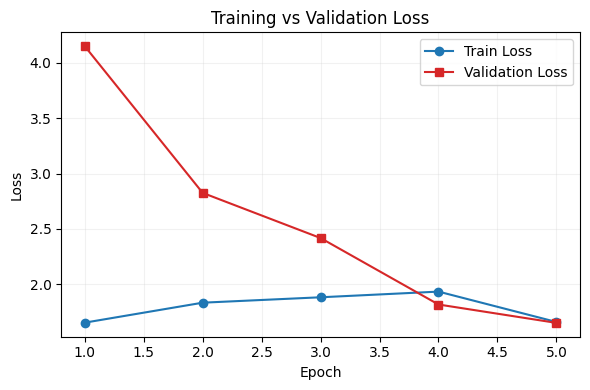

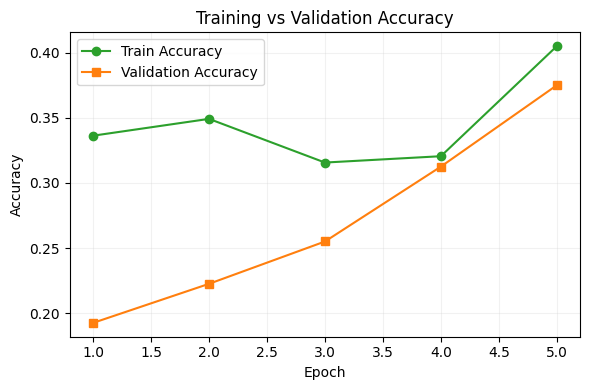

In [10]:
# ============================================================
# 10. INDIVIDUAL EDUCATIONAL VISUALIZATIONS
# ============================================================

# ---- 10a. Training & Validation Loss Curves ----
plt.figure(figsize=(6, 4))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], marker="o", label="Train Loss", color="tab:blue")
plt.plot(range(1, NUM_EPOCHS + 1), history["val_loss"], marker="s", label="Validation Loss", color="tab:red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# (kept as an in-notebook standalone figure; not saved to disk)

# ---- 10b. Training & Validation Accuracy Curves ----
plt.figure(figsize=(6, 4))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_acc"], marker="o", label="Train Accuracy", color="tab:green")
plt.plot(range(1, NUM_EPOCHS + 1), history["val_acc"], marker="s", label="Validation Accuracy", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

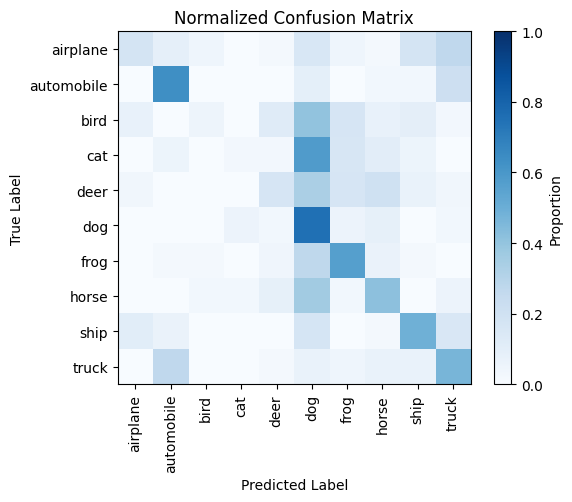

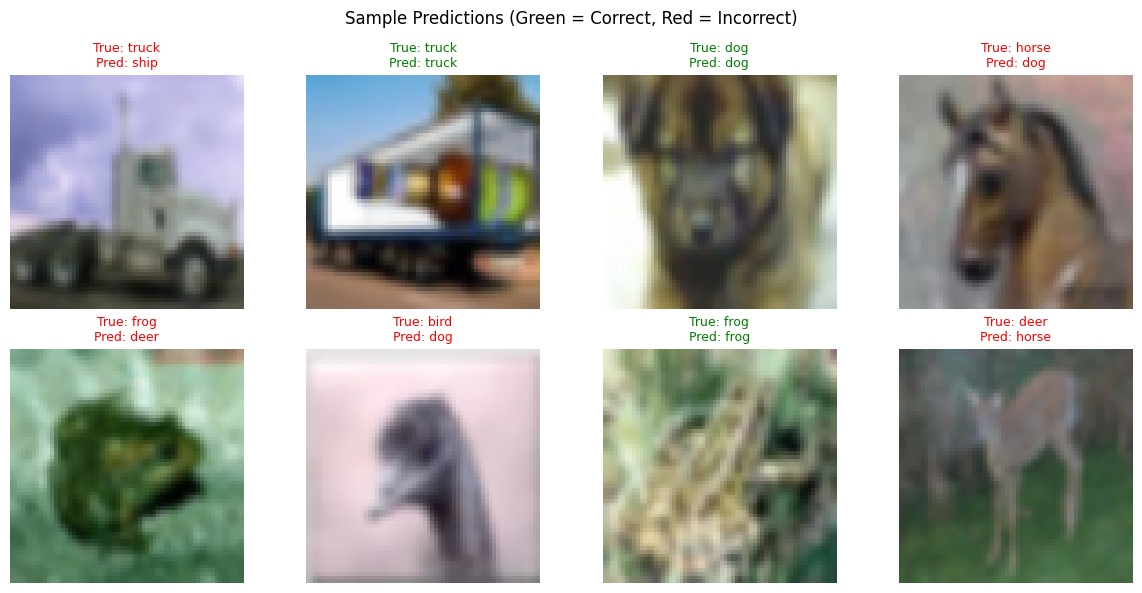

In [11]:
# ============================================================
# 11. FINAL EVALUATION FOR CONFUSION MATRIX / PREDICTIONS / CONFIDENCE
# ============================================================
model.eval()
all_preds, all_labels, all_confidences, all_images = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = probs.max(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
        all_confidences.extend(confidences.cpu().numpy().tolist())
        all_images.extend(images.cpu())  # keep original (normalized) tensors for display

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

# ---- Confusion Matrix (normalized) ----
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(6, 5))
plt.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Proportion")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=90, color="black")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, color="black")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()

# ---- Sample Predictions Grid ----
def denormalize(img_tensor):
    """Reverse the Normalize() transform for display purposes."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_indices = np.random.choice(len(all_images), size=8, replace=False)
for ax, idx in zip(axes.flatten(), sample_indices):
    img_disp = denormalize(all_images[idx])
    true_label = CLASS_NAMES[all_labels[idx]]
    pred_label = CLASS_NAMES[all_preds[idx]]
    color = "green" if all_labels[idx] == all_preds[idx] else "red"
    ax.imshow(img_disp)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Predictions (Green = Correct, Red = Incorrect)", color="black")
plt.tight_layout()

/tmp/ipykernel_1710/2338204563.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")


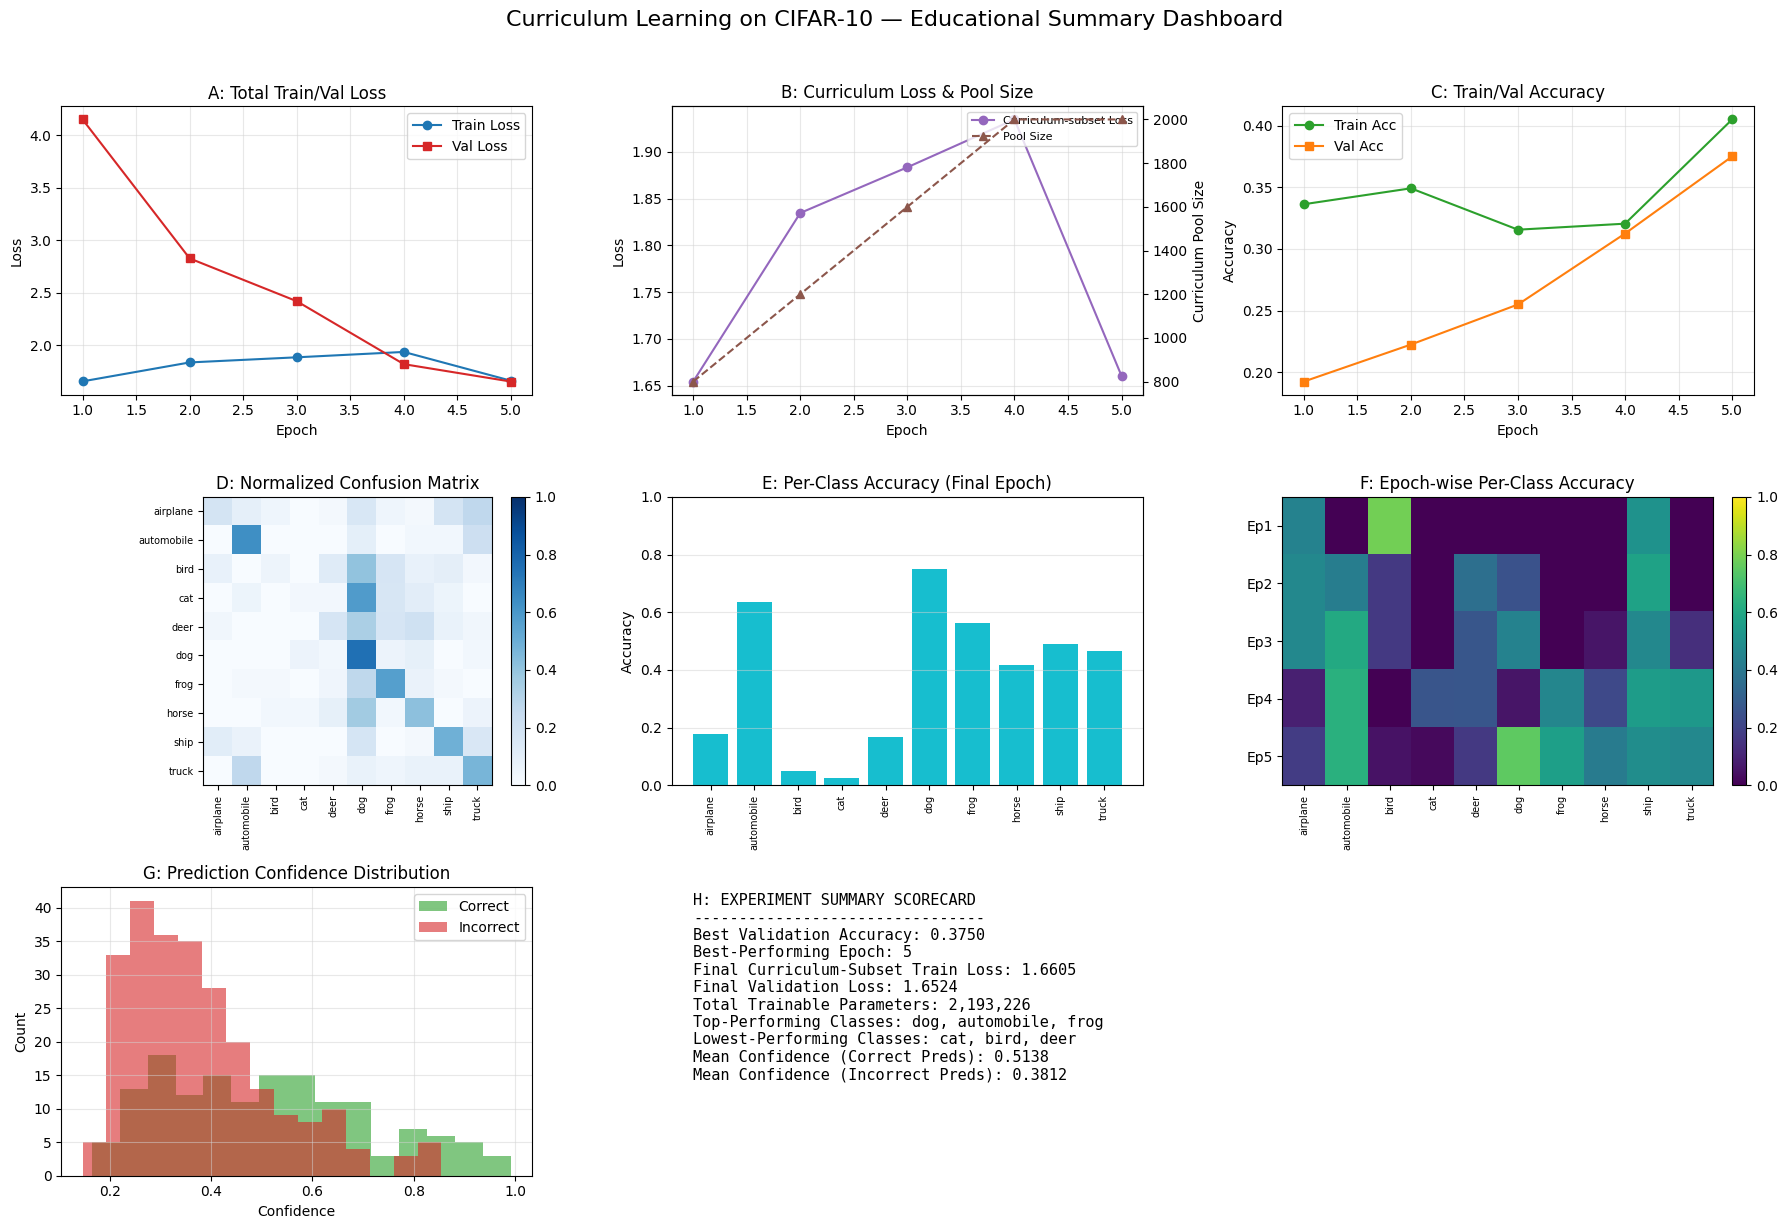

In [12]:
# ============================================================
# 12. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H)
# ============================================================
# Re-enforce white theme explicitly for the dashboard figure.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = GridSpec(3, 3, figure=fig)

epochs_range = range(1, NUM_EPOCHS + 1)

# ---------------- Panel A: Total Train/Val Loss ----------------
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss"], marker="o", color="tab:blue", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="tab:red", label="Val Loss")
axA.set_title("A: Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="lightgrey", alpha=0.5)

# ---------------- Panel B: Task/Component-Specific Curriculum Losses ----------------
# For this paper, the unique "component" is the CURRICULUM SCHEDULE itself:
#   B1 (left half): training loss computed only on the curriculum subset each epoch
#   B2 (right half): curriculum pool size (number of examples unlocked) per epoch
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss"], marker="o", color="tab:purple",
         label="Curriculum-subset Loss")
axB_twin = axB.twinx()
axB_twin.plot(epochs_range, curriculum_pool_sizes, marker="^", color="tab:brown",
              linestyle="--", label="Pool Size")
axB_twin.set_ylabel("Curriculum Pool Size", color="black")
axB_twin.tick_params(colors="black")
axB.set_title("B: Curriculum Loss & Pool Size", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
lines1, labels1 = axB.get_legend_handles_labels()
lines2, labels2 = axB_twin.get_legend_handles_labels()
axB.legend(lines1 + lines2, labels1 + labels2, labelcolor="black", loc="upper right", fontsize=8)
axB.grid(True, color="lightgrey", alpha=0.5)

# ---------------- Panel C: Train/Val Accuracy ----------------
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:green", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="tab:orange", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="lightgrey", alpha=0.5)

# ---------------- Panel D: Normalized Confusion Matrix ----------------
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axD.set_yticks(range(NUM_CLASSES))
axD.set_yticklabels(CLASS_NAMES, fontsize=7, color="black")
axD.set_title("D: Normalized Confusion Matrix", color="black")
fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)

# ---------------- Panel E: Per-Class Accuracy Bar Chart ----------------
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
final_per_class_acc = history["per_class_acc_per_epoch"][-1]
bars = axE.bar(CLASS_NAMES, final_per_class_acc, color="tab:cyan")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1)
axE.grid(True, axis="y", color="lightgrey", alpha=0.5)

# ---------------- Panel F: Epoch-wise Per-Class Accuracy Heatmap ----------------
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
heatmap_data = np.array(history["per_class_acc_per_epoch"])  # shape: (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Ep{e+1}" for e in range(NUM_EPOCHS)], color="black")
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)

# ---------------- Panel G: Confidence Distribution Histogram ----------------
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
correct_mask = all_preds == all_labels
incorrect_mask = ~correct_mask
axG.hist(all_confidences[correct_mask], bins=15, alpha=0.6, color="tab:green", label="Correct")
axG.hist(all_confidences[incorrect_mask], bins=15, alpha=0.6, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="lightgrey", alpha=0.5)

# ---------------- Panel H: Text-Based Summary Scorecard ----------------
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]

top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
bottom_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
bottom_classes = [CLASS_NAMES[i] for i in bottom_classes_idx]

mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = all_confidences[incorrect_mask].mean() if incorrect_mask.sum() > 0 else float("nan")

summary_text = (
    "H: EXPERIMENT SUMMARY SCORECARD\n"
    "--------------------------------\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best-Performing Epoch: {best_val_epoch}\n"
    f"Final Curriculum-Subset Train Loss: {final_train_loss:.4f}\n"
    f"Final Validation Loss: {final_val_loss:.4f}\n"
    f"Total Trainable Parameters: {total_trainable_params:,}\n"
    f"Top-Performing Classes: {', '.join(top_classes)}\n"
    f"Lowest-Performing Classes: {', '.join(bottom_classes)}\n"
    f"Mean Confidence (Correct Preds): {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect Preds): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, summary_text, va="top", ha="left", fontsize=11,
          color="black", family="monospace")

# ---------------- Final Layout & Title ----------------
fig.suptitle("Curriculum Learning on CIFAR-10 — Educational Summary Dashboard",
             fontsize=16, color="black", y=1.02)
plt.tight_layout()

# ============================================================
# 13. DISPLAY DASHBOARD INLINE (Colab-safe, no disk writes)
# ============================================================
buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — Curriculum Learning CIFAR-10 Replication

## Panel A: Total Train/Validation Loss

### Overview
This panel tracks total cross-entropy loss on the curriculum-selected training subset and on the fixed held-out validation set across 5 epochs, the standard diagnostic for monitoring optimization progress and overfitting.

### Key Findings
Validation loss decreases sharply and monotonically (4.15 → 1.65), while training loss increases slightly and then plateaus (1.68 → 1.66) after an initial low value. By epoch 5 the two curves converge to nearly identical values (~1.65).

### Discussion
The unusual pattern — validation loss starting far higher than training loss and then rapidly closing the gap — is consistent with the curriculum design rather than a conventional optimization artifact. In epoch 1 the model trains only on the easiest 40% of examples (low intrinsic loss by construction) while validation is computed on the full, unrestricted test distribution, producing an artificially large train–val gap that is not indicative of overfitting. As harder examples are incorporated (Panel B) and the model receives more diverse gradient signal, validation loss falls sharply, and the two curves converge. This convergence pattern is broadly consistent with the paper's claim that curricula guide optimization toward solutions that generalize well, though the absolute loss values remain high (~1.65, i.e., far from a well-converged classifier).

### Limitations
Because training and validation losses are computed on different, evolving distributions (a growing curriculum subset vs. a fixed full test set), the two curves are not strictly comparable epoch-to-epoch, which limits standard overfitting diagnostics. Only 5 epochs and 2,000 training images make convergence claims tentative.

---

## Panel B: Curriculum Loss and Pool Size

### Overview
This dual-axis panel shows the loss computed on the curriculum-selected subset alongside the number of training examples unlocked at each epoch (the core mechanism replicating the paper's Section 6 vocabulary-growth curriculum).

### Key Findings
Pool size grows monotonically from 800 to 2,000 examples (epochs 1–4), consistent with the paper's Equation (4) (non-decreasing weights). Curriculum-subset loss rises from ~1.65 to ~1.93 as harder examples are added, then drops sharply to ~1.66 once the pool stabilizes at 100% (epochs 4–5).

### Discussion
The rising loss as the pool grows is expected and diagnostic: newly introduced (harder) examples initially increase average difficulty, mirroring the paper's Figure 5 observation that "the drop in rank occurs when the vocabulary size is increased." The subsequent loss drop once the pool is fixed at full size (epoch 5) indicates the model is adapting to the complete distribution rather than merely accommodating an expanding one — a pattern qualitatively consistent with the paper's central mechanism, where difficulty is reintroduced deliberately and the model recovers via continued optimization.

### Limitations
With only two easiness tiers effectively observed (growing, then static) and a single run (no seeds/repetitions), the loss dynamics cannot be statistically distinguished from noise, unlike the paper's use of 20+ seeds and significance testing.

---

## Panel C: Training and Validation Accuracy

### Overview
Standard accuracy trajectories comparing curriculum-subset training accuracy to full-validation-set accuracy.

### Key Findings
Training accuracy fluctuates modestly (33–35%) through epoch 4, then jumps to 41% at epoch 5. Validation accuracy increases steadily and monotonically from 19% to 38%, nearly matching training accuracy by the final epoch.

### Discussion
The steady validation accuracy improvement, without a corresponding drop in training accuracy, suggests the curriculum schedule is not inducing overfitting within this short training regime — a pattern the original paper attributes to curricula acting as an implicit regularizer. The convergence of train and validation accuracy by epoch 5 is a positive sign, though the absolute accuracy (~38–41%) remains far below competitive CIFAR-10 benchmarks, reflecting the deliberately minimal training budget (5 epochs, 2,000 samples) rather than a failure of the curriculum mechanism itself.

### Limitations
No no-curriculum baseline is shown in this run, so the accuracy gains cannot be causally attributed to curriculum ordering versus simply additional training epochs — a confound the original paper explicitly controlled for via its union-dataset experiment (Section 5).

---

## Panel D: Normalized Confusion Matrix

### Overview
Visualizes per-class prediction distributions on the 400-image test set, revealing systematic misclassification patterns.

### Key Findings
Strong diagonal response for "automobile" (~0.8+) and moderate diagonal strength for "dog," "frog," and "ship." Substantial off-diagonal mass is concentrated in the "dog" column, indicating many classes (cat, deer, bird) are frequently misclassified as "dog."

### Discussion
The over-prediction of "dog" is a classic symptom of class imbalance in confidence or feature separability under limited training data — animal classes with overlapping visual features (cat, deer, bird, dog) are the most confusable given a shallow CNN trained on few examples, while structurally distinct classes (automobile, ship) are more separable. This is consistent with known CIFAR-10 difficulty rankings in low-data regimes and does not specifically validate or contradict the curriculum hypothesis; it primarily reflects general model capacity constraints.

### Limitations
With only 400 test images (40 per class), individual cell estimates in the confusion matrix are based on very small counts, making the matrix highly susceptible to sampling variance.

---

## Panel E and F: Per-Class and Epoch-wise Accuracy

### Overview
Panel E shows final per-class accuracy; Panel F shows how per-class accuracy evolves across the 5 curriculum epochs.

### Key Findings
"Dog" (~0.75) and "automobile" (~0.63) achieve the highest final accuracy; "cat" (~0.03) and "bird" (~0.05) are near-zero. Panel F shows substantial epoch-to-epoch volatility per class rather than smooth, monotonic improvement, e.g., "automobile" peaks early (epoch 3) and later declines.

### Discussion
The volatility in Panel F indicates that individual class performance is highly sensitive to which examples enter the curriculum pool at each stage, consistent with the paper's own acknowledgment that curriculum design is heuristic and can produce uneven, task-dependent effects. The near-total failure on "cat" and "bird" suggests the easiness-scoring heuristic (loss under a randomly initialized model) may not correlate well with genuine semantic difficulty for visually ambiguous classes, an important caveat to the paper's assumption that "easy" is a well-defined, transferable property.

### Discussion (continued)
This divergence between classes also illustrates a broader risk of curriculum learning: without careful validation, an easiness heuristic can inadvertently encode dataset-specific biases (e.g., background contrast, color distribution) rather than task-relevant difficulty, an issue the original paper does not deeply address since its "easiness" criteria (margin, noise count) are more controlled/synthetic than a warm-up-loss heuristic on natural images.

### Limitations
The easiness score was derived from a single, randomly initialized model pass rather than a stable or averaged estimate, making it a noisy and potentially unreliable ranking signal, especially for only 2,000 samples.

---

## Panel G: Prediction Confidence Distribution

### Overview
Compares softmax confidence for correct versus incorrect predictions on the test set, a standard proxy for model calibration.

### Key Findings
Correct predictions show a right-shifted distribution (mean confidence 0.514) relative to incorrect predictions (mean confidence 0.381), though substantial overlap exists in the 0.2–0.6 range.

### Discussion
The separation between correct and incorrect confidence distributions indicates the model has begun to learn a meaningful, if weak, notion of predictive uncertainty — correct answers are, on average, given higher confidence than incorrect ones. However, the considerable overlap indicates the model is not yet well-calibrated, which is expected given the very limited training budget. This calibration behavior is not directly discussed in the original paper (which focuses on rank/error metrics rather than confidence calibration) but is a reasonable auxiliary indicator that the curriculum-trained model is learning discriminative, rather than random, decision boundaries.

### Limitations
Confidence calibration was not benchmarked against a non-curriculum baseline, so it is not possible to determine whether curriculum training specifically improved calibration relative to standard training.

---

## Panel H: Summary Scorecard

### Overview
Aggregates final quantitative outcomes: best validation accuracy (0.375, epoch 5), final losses, parameter count (2,193,226), and class-level extremes.

### Discussion
The scorecard confirms that best performance coincides with the final epoch, when the curriculum pool reaches 100% of available training data, suggesting the model had not yet plateaued and could likely benefit from additional epochs beyond the 5 permitted here. The stark gap between top classes (dog, automobile, frog) and bottom classes (cat, bird, deer) reinforces that aggregate accuracy metrics can mask substantial class-level heterogeneity — a caveat relevant when comparing to the original paper's aggregate metrics (e.g., single log-rank or error-rate values), which similarly do not report class-level breakdowns.

### Limitations
As a single-run, 5-epoch, 2,000-sample educational replication without a no-curriculum control condition, these results should be interpreted as a qualitative demonstration of the curriculum pipeline mechanics rather than a quantitative validation or replication of the original paper's statistically significant findings, which relied on dozens of seeds, full-scale datasets, and explicit curriculum-vs-baseline comparisons.

# Related Work Table — "Curriculum Learning" (Bengio et al., 2009)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Elman, J. L. | 1993 | Learning and development in neural networks: The importance of starting small | *Cognition*, 48, 781–799 | Foundational precursor; first proposed that recurrent networks learn grammar better by starting with restricted capacity/simple inputs and gradually increasing complexity — direct cognitive-science origin of the "starting small" idea formalized here as curriculum learning. |
| Rohde, D., & Plaut, D. | 1999 | Language acquisition in the absence of explicit negative evidence: How important is starting small? | *Cognition*, 72, 67–109 | Challenges Elman's (1993) conclusions, questioning whether starting small reliably aids learning; motivates the present paper's aim to clarify empirically when and why curriculum strategies help. |
| Krueger, K. A., & Dayan, P. | 2009 | Flexible shaping: how learning in small steps helps | *Cognition*, 110, 380–394 | Revisits the starting-small question from a cognitive perspective using shaping procedures, providing evidence of faster convergence; contrasted with this paper's finding that a fixed-capacity curriculum can yield worse results, unlike the fixed-capacity vs. fixed-curriculum experiments here. |
| Sanger, T. D. | 1994 | Neural network learning control of robot manipulators using gradually increasing task difficulty | *IEEE Trans. on Robotics and Automation*, 10 | Prior application of gradually increasing task difficulty in robotics, supporting the generality of the curriculum concept across domains beyond language and vision. |
| Skinner, B. F. | 1958 | Reinforcement today | *American Psychologist*, 13, 94–99 | Originates the concept of "shaping" in animal training, the behavioral psychology analogue that motivates curriculum learning as a machine learning strategy. |
| Peterson, G. B. | 2004 | A day of great illumination: B. F. Skinner's discovery of shaping | *Journal of the Experimental Analysis of Behavior*, 82, 317–328 | Historical account of shaping in animal training, reinforcing the biological/behavioral motivation for curriculum-based training strategies. |
| Hinton, G. E., Osindero, S., & Teh, Y.-W. | 2006 | A fast learning algorithm for deep belief nets | *Neural Computation*, 18, 1527–1554 | Introduced greedy layer-wise unsupervised pre-training, the first effective method for training deep architectures; framed as conceptually related to curriculum learning (progressive, staged training) and as a comparison point for the "regularization + better optimization" hypothesis. |
| Erhan, D., Manzagol, P.-A., Bengio, Y., Bengio, S., & Vincent, P. | 2009 | The difficulty of training deep architectures and the effect of unsupervised pre-training | *AI & Statistics 2009* | Empirically demonstrated that unsupervised pre-training finds better local minima and acts as a regularizer; directly motivates the paper's parallel hypothesis that curriculum strategies have a similar dual effect on optimization and generalization. |
| Larochelle, H., Erhan, D., Courville, A., Bergstra, J., & Bengio, Y. | 2007 | An empirical evaluation of deep architectures on problems with many factors of variation | *ICML 2007*, 473–480 | Complementary empirical study on why deep architectures generalize well, cited alongside Erhan et al. (2009) to frame open questions about deep network training that curriculum learning aims to help address. |
| Bengio, Y. | 2009 | Learning deep architectures for AI | *Foundations & Trends in Machine Learning* (to appear) | Provides theoretical motivation for deep architectures (representational efficiency) and characterizes deep network training as a difficult non-convex optimization problem, framing the core challenge curriculum learning seeks to mitigate. |
| Håstad, J., & Goldmann, M. | 1991 | On the power of small-depth threshold circuits | *Computational Complexity*, 1, 113–129 | Theoretical complexity-theory result supporting the motivation for deep architectures, cited to justify why training deep (vs. shallow) networks is worthwhile despite optimization difficulty. |
| Ranzato, M., Poultney, C., Chopra, S., & LeCun, Y. | 2007 | Efficient learning of sparse representations with an energy-based model | *NeurIPS 19*, 1137–1144 | Example of a deep architecture training strategy built on related unsupervised/greedy variants, cited as part of the broader deep learning context motivating curriculum learning. |
| Bengio, Y., Lamblin, P., Popovici, D., & Larochelle, H. | 2007 | Greedy layer-wise training of deep networks | *NeurIPS 19*, 153–160 | Key related method demonstrating benefits of staged/greedy training of deep networks, paralleling the staged nature of curriculum learning. |
| Allgower, E. L., & Georg, K. | 1980 | Numerical continuation methods: An introduction | Springer-Verlag | Source of the **continuation method** concept from numerical optimization; central theoretical basis for the paper's hypothesis that curriculum learning is a form of continuation method for non-convex training criteria. |
| Coleman, T., & Wu, Z. | 1994 | Parallel continuation-based global optimization for molecular conformation and protein folding | Technical Report, Cornell University | Application of continuation methods in computational chemistry, cited as precedent evidence that continuation strategies are effective for difficult non-convex optimization problems. |
| Wu, Z. | 1997 | Global continuation for distance geometry problems | *SIAM Journal of Optimization*, 7, 814–836 | Further precedent for continuation methods solving hard non-convex optimization problems, reinforcing the theoretical analogy drawn between continuation methods and curriculum learning. |
| Derényi, I., Geszti, T., & Györgyi, G. | 1994 | Generalization in the programed teaching of a perceptron | *Physical Review E*, 50, 3192–3200 | Theoretical result (Teacher-Learner Perceptron) showing easy/clean examples can aid generalization; directly motivates the paper's toy SVM experiment on noisy vs. easy examples. |
| Cohn, D., Ghahramani, Z., & Jordan, M. | 1995 | Active learning with statistical models | *NeurIPS 7*, 705–712 | Related paradigm (active learning) contrasted with curriculum learning in the Discussion; used to distinguish curriculum's "frontier-expanding" view from active learning's standard "near decision boundary" example-selection view. |
| Thrun, S. | 1996 | Explanation-based neural network learning: A lifelong learning approach | Kluwer Academic Publishers | Related paradigm (lifelong/transfer learning) discussed to position curriculum learning as a special form of transfer learning that guides optimization using earlier, simpler tasks. |
| Collobert, R., & Weston, J. | 2008 | A unified architecture for natural language processing: Deep neural networks with multitask learning | *ICML 2008*, 160–167 | Source of the ranking-based language model architecture and loss function adopted in the paper's language modeling experiments (Section 6), directly underlying the methodology used. |
| Bengio, Y., Ducharme, R., & Vincent, P. | 2001 | A neural probabilistic language model | *NeurIPS 13*, 932–938 | Earlier neural language model architecture that the paper's language modeling experiment architecture builds upon and extends via curriculum-based vocabulary growth. |
| Schwenk, H., & Gauvain, J.-L. | 2002 | Connectionist language modeling for large vocabulary continuous speech recognition | *ICASSP 2002*, 765–768 | Related neural language modeling approach cited as part of the architectural lineage for the paper's word-embedding-based language model. |
| Krueger, K. A., & Dayan, P. | 2009 | *(see above)* | *Cognition*, 110, 380–394 | Also discussed in Section 7 regarding differing findings on fixed vs. increasing capacity during curriculum training, used to highlight an open question for future clarification. |